In [1]:
import spatial_analysis_tools as sat
import tifffile
import seaborn as sns
import matplotlib.pyplot as plt

file_path = 'Z:\\Mikala\\connectivity\\09012025\\09012025_mtlRNAi_HMC03186_dapi_488_555_647_ovary1_ch1_downs_cp_masks_refined.tif'
file_path = 'Z:\\Mikala\\connectivity\\09092025\\09092025_nosdlg1RNAi1_dapi_488_555_647_ovary1_ch1_downs_cp_masks_refined.tif'
px_size = [0.25, 0.14, 0.14]  # Z, Y, X in micrometers

# Load refined masks
masks = tifffile.imread(file_path)

# Analyze neighbor relationships
cell_metrics, G, summary = sat.analyzeVASANeighbors(masks, noise_threshold=5, px_size=px_size)

print(summary)
cell_metrics.head()

[analyzeVASANeighbors] 93 cells, 1 clusters, 0 isolated cells
{'n_cells': 93, 'n_clusters': 1, 'mean_cluster_size': 93.0, 'median_cluster_size': 93.0, 'n_isolated_cells': 0}


,label,centroid_z,centroid_y,centroid_x,vasa_neighbors,cluster_size,vasa_surface,non_vasa_surface,total_surface,shared_boundary_ratio,clustering_coeff
0,1,22.478344,232.551015,130.624933,2,93,36.2124,150.5448,186.7572,0.193901,0.000000
1,2,28.176179,198.343486,135.360706,2,93,27.2930,180.9990,208.2920,0.131032,0.000000
2,3,25.531691,293.093469,124.809943,4,93,63.6762,110.2150,173.8912,0.366184,0.666667
3,4,28.871394,255.825903,110.568732,5,93,83.1782,117.9374,201.1156,0.413584,0.500000
4,5,34.584530,285.816392,170.366683,1,93,8.3314,184.0790,192.4104,0.043300,0.000000


In [1]:
import spatial_analysis_tools as sat
import tifffile
import pandas as pd
import os

px_size = [0.25, 0.14, 0.14]

# --- INPUTS ---
folders    = ['Z:\\Mikala\\connectivity\\09012025\\', 'Z:\\Mikala\\connectivity\\09092025\\','Z:\\Mikala\\connectivity\\09092025\\']
folders    = ['Z:\\Mikala\\connectivity\\09072025\\', 'Z:\\Mikala\\connectivity\\09072025\\']
conditions = ['atpalphaRNAi', 'control', 'control']
# --------------

all_results = pd.DataFrame()
all_summaries = pd.DataFrame()

for masksFolder, condition in zip(folders, conditions):
    maskFiles = [f for f in os.listdir(masksFolder)
                 if f.endswith('masks_refined.tif') and condition in f]

    print(f'\n=== {condition}: found {len(maskFiles)} files in {masksFolder} ===')

    for f in maskFiles:
        print(f'  Processing: {f}')
        label_image = tifffile.imread(os.path.join(masksFolder, f))

        cell_metrics, G, summary = sat.analyzeVASANeighbors(label_image, noise_threshold=5, px_size=px_size)

        dataset = f.split('_ch')[0]
        cell_metrics['dataset'] = dataset
        cell_metrics['condition'] = condition

        summary['dataset'] = dataset
        summary['condition'] = condition

        all_results = pd.concat([all_results, cell_metrics], ignore_index=True)
        all_summaries = pd.concat([all_summaries, pd.DataFrame([summary])], ignore_index=True)

print(f'\nDone. {len(all_results)} total cells, {len(all_summaries)} samples')
all_summaries


=== atpalphaRNAi: found 10 files in Z:\Mikala\connectivity\09072025\ ===
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary1_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 140 cells, 1 components (LCC=140), 0 isolated, FI=0.000
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary2_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 131 cells, 3 components (LCC=127), 0 isolated, FI=0.031
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary3_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 231 cells, 2 components (LCC=230), 1 isolated, FI=0.004
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary4_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 86 cells, 1 components (LCC=86), 0 isolated, FI=0.000
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary5_ch1_downs_cp_masks_refined.tif
[analyzeVASANeighbors] 84 cells, 2 components (LCC=82), 0 isolated, FI=0.024
  Processing: 09072025_atpalphaRNAi1_dapi_488_555_647_ovary6_ch1_downs_cp_m

,n_cells,n_components,n_clusters,lcc_size,fragmentation_index,component_sizes,mean_cluster_size,median_cluster_size,n_isolated_cells,frac_isolated,mean_k,std_k,mean_CC_defined,frac_CC_undefined,mean_volume_um3,mean_diameter_um,dataset,condition
0,140,1,1,140,0.000000,[140],140.000000,140.0,0,0.000000,5.414286,2.121272,0.468639,0.021429,132.317710,6.290687,09072025_atpalphaRNAi1_dapi_488_555_647_ovary1,atpalphaRNAi
1,131,3,3,127,0.030534,"[127, 2, 2]",43.666667,2.0,0,0.000000,4.351145,2.161155,0.437224,0.083969,151.897606,6.579970,09072025_atpalphaRNAi1_dapi_488_555_647_ovary2,atpalphaRNAi
2,231,2,2,230,0.004329,"[230, 1]",115.500000,115.5,1,0.004329,5.887446,2.478543,0.488845,0.030303,105.575103,5.826012,09072025_atpalphaRNAi1_dapi_488_555_647_ovary3,atpalphaRNAi
3,86,1,1,86,0.000000,[86],86.000000,86.0,0,0.000000,4.465116,1.604483,0.414525,0.034884,104.514322,5.808103,09072025_atpalphaRNAi1_dapi_488_555_647_ovary4,atpalphaRNAi
4,84,2,2,82,0.023810,"[82, 2]",42.000000,42.0,0,0.000000,3.928571,1.764638,0.328089,0.059524,152.917275,6.610533,09072025_atpalphaRNAi1_dapi_488_555_647_ovary5,atpalphaRNAi
5,127,2,2,126,0.007874,"[126, 1]",63.500000,63.5,1,0.007874,4.535433,1.926995,0.451469,0.047244,133.311368,6.299148,09072025_atpalphaRNAi1_dapi_488_555_647_ovary6,atpalphaRNAi
6,185,6,6,179,0.032432,"[179, 2, 1, 1, 1, 1]",30.833333,1.0,4,0.021622,5.145946,2.298130,0.443387,0.054054,144.727248,6.478963,09072025_atpalphaRNAi2_dapi_488_555_647_ovary1,atpalphaRNAi
7,172,2,2,171,0.005814,"[171, 1]",86.000000,86.0,1,0.005814,4.848837,2.093831,0.428795,0.052326,116.560630,6.022193,09072025_atpalphaRNAi2_dapi_488_555_647_ovary2,atpalphaRNAi
8,146,2,2,144,0.013699,"[144, 2]",73.000000,73.0,0,0.000000,5.095890,2.107809,0.458742,0.047945,152.897083,6.603028,09072025_atpalphaRNAi2_dapi_488_555_647_ovary3,atpalphaRNAi
9,144,3,3,142,0.013889,"[142, 1, 1]",48.000000,1.0,2,0.013889,5.500000,2.426703,0.472328,0.041667,113.618580,5.974473,09072025_atpalphaRNAi2_dapi_488_555_647_ovary4,atpalphaRNAi


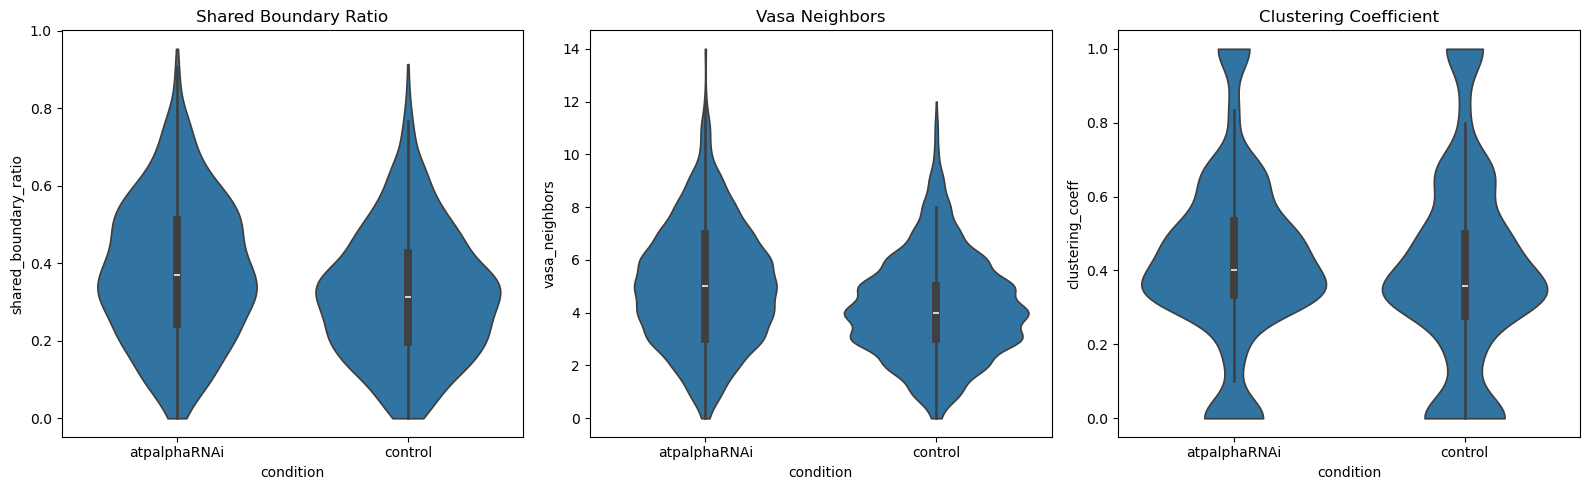

In [26]:
# Per-cell violin plots: compare distributions between conditions
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.violinplot(data=all_results, x='condition', y='shared_boundary_ratio', ax=axes[0], cut=0)
axes[0].set_title('Shared Boundary Ratio')

sns.violinplot(data=all_results, x='condition', y='vasa_neighbors', ax=axes[1], cut=0)
axes[1].set_title('Vasa Neighbors')

sns.violinplot(data=all_results, x='condition', y='clustering_coeff', ax=axes[2], cut=0)
axes[2].set_title('Clustering Coefficient')

plt.tight_layout()
plt.show()

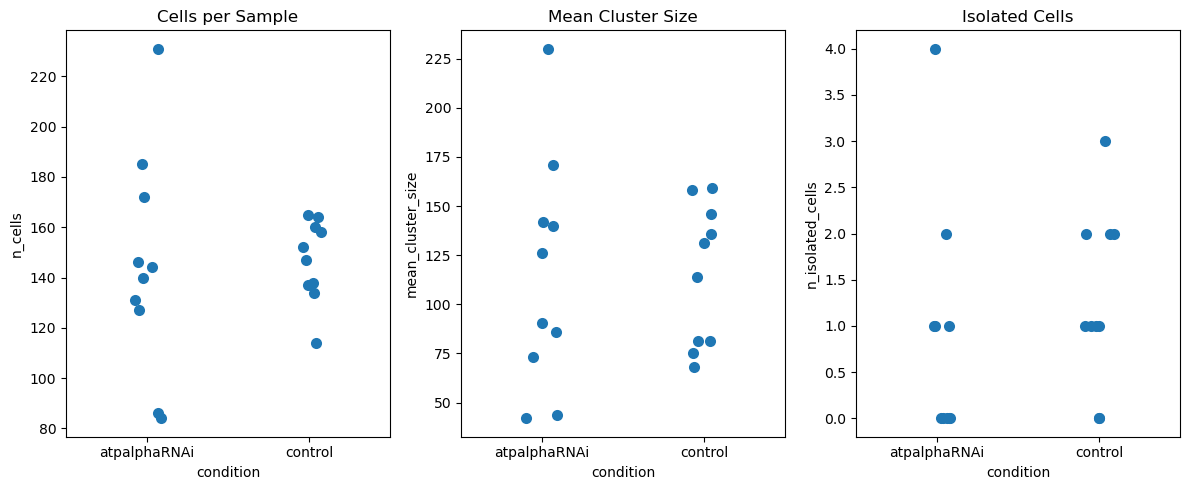

In [27]:
# Per-sample strip plots: each ovary as a dot
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.stripplot(data=all_summaries, x='condition', y='n_cells', ax=axes[0], size=8, jitter=True)
axes[0].set_title('Cells per Sample')

sns.stripplot(data=all_summaries, x='condition', y='mean_cluster_size', ax=axes[1], size=8, jitter=True)
axes[1].set_title('Mean Cluster Size')

sns.stripplot(data=all_summaries, x='condition', y='n_isolated_cells', ax=axes[2], size=8, jitter=True)
axes[2].set_title('Isolated Cells')

plt.tight_layout()
plt.show()

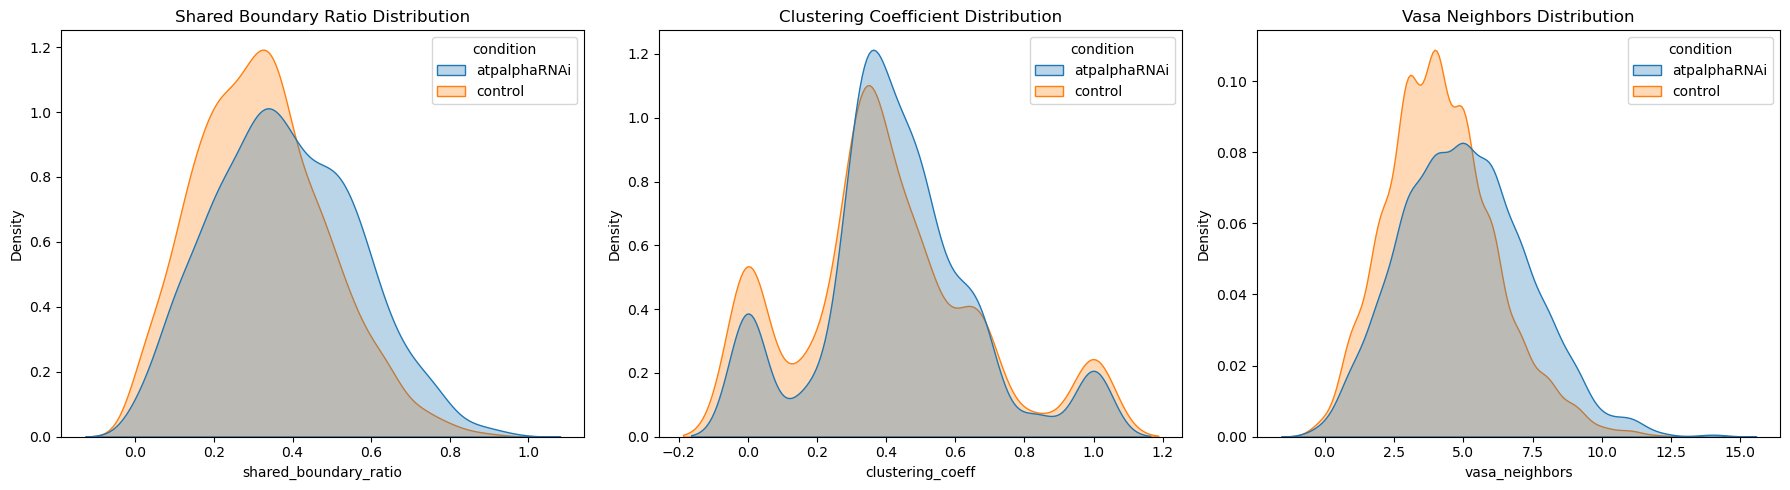

In [28]:
# Overlaid KDEs: distribution shape comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(data=all_results, x='shared_boundary_ratio', hue='condition', fill=True, alpha=0.3, ax=axes[0])
axes[0].set_title('Shared Boundary Ratio Distribution')

sns.kdeplot(data=all_results, x='clustering_coeff', hue='condition', fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Clustering Coefficient Distribution')

#sns.histplot(data=all_results, x='vasa_neighbors', hue='condition', fill=True, alpha=0.3, ax=axes[2])
sns.kdeplot(data=all_results, x='vasa_neighbors', hue='condition',  ax=axes[2], alpha=0.3, fill=True)
axes[2].set_title('Vasa Neighbors Distribution')

plt.tight_layout()
plt.show()

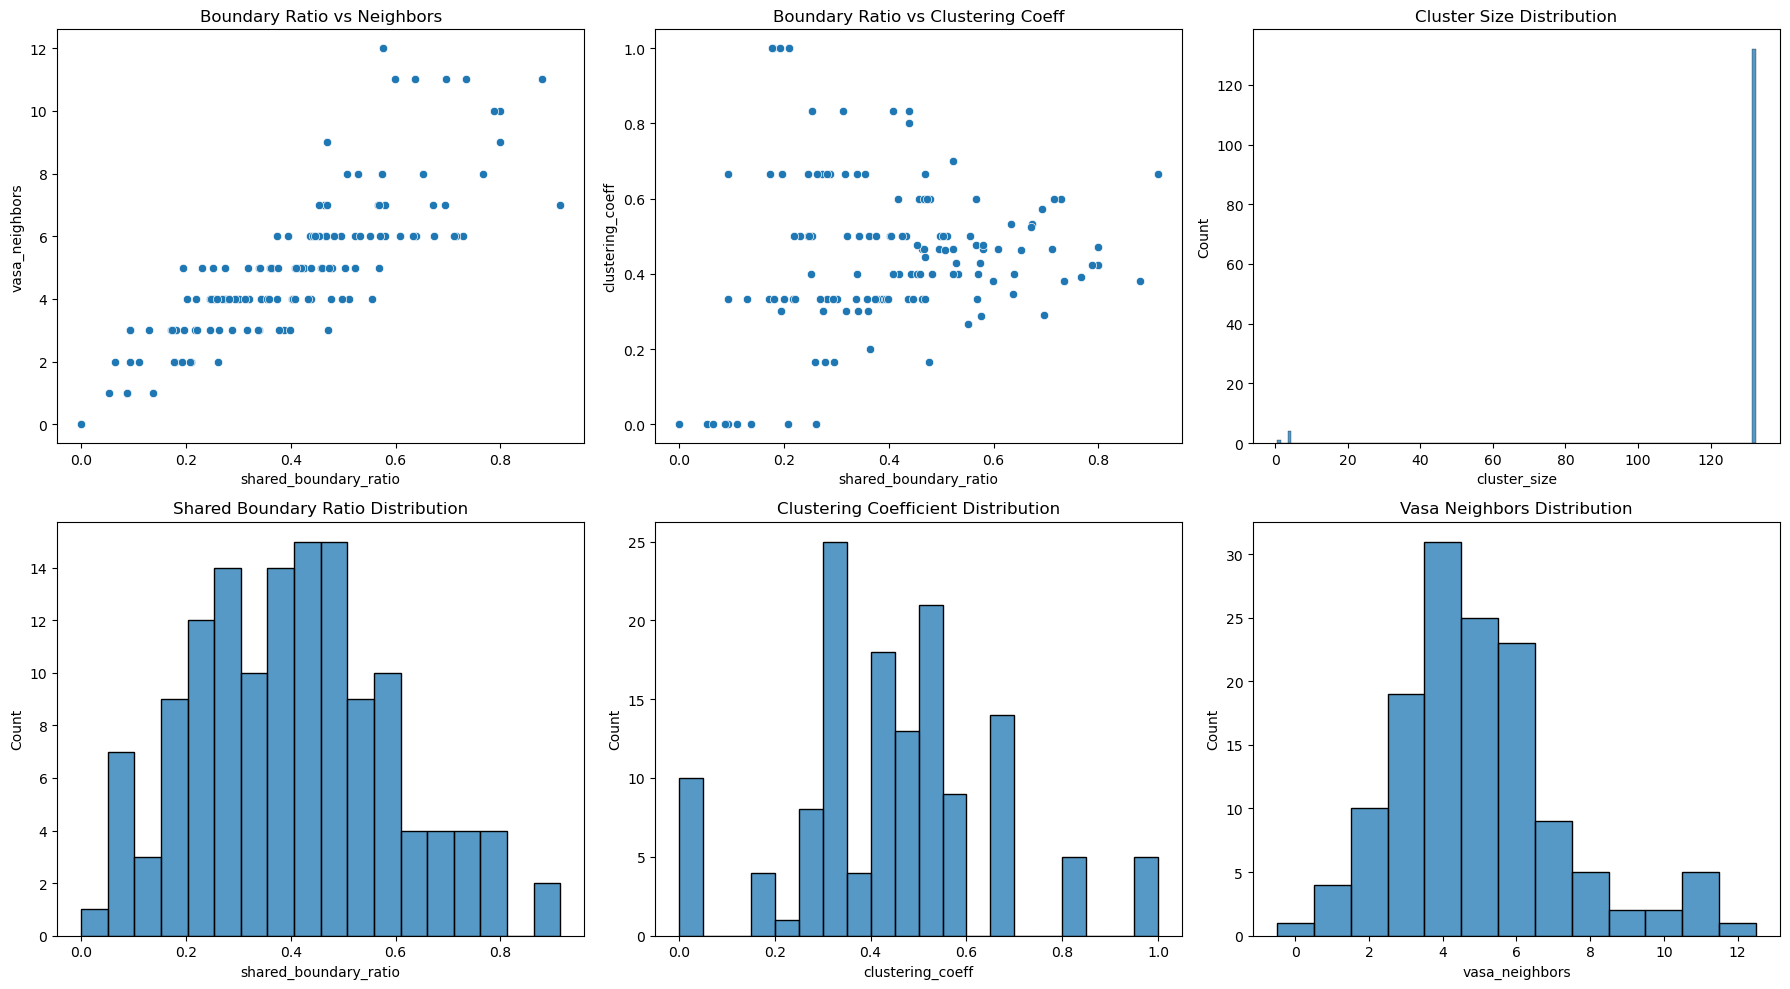

In [29]:
# Visualize metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.scatterplot(data=cell_metrics, x="shared_boundary_ratio", y="vasa_neighbors", ax=axes[0,0])
axes[0,0].set_title('Boundary Ratio vs Neighbors')

sns.scatterplot(data=cell_metrics, x="shared_boundary_ratio", y="clustering_coeff", ax=axes[0,1])
axes[0,1].set_title('Boundary Ratio vs Clustering Coeff')

sns.histplot(data=cell_metrics, x="cluster_size", discrete=True, ax=axes[0,2])
axes[0,2].set_title('Cluster Size Distribution')


sns.histplot(data=cell_metrics, x="shared_boundary_ratio",  ax=axes[1,0], binwidth=0.05)
axes[1,0].set_title('Shared Boundary Ratio Distribution')

sns.histplot(data=cell_metrics, x="clustering_coeff", ax=axes[1,1], binwidth=0.05)
axes[1,1].set_title('Clustering Coefficient Distribution')

sns.histplot(data=cell_metrics, x="vasa_neighbors", ax=axes[1,2],binwidth=1, discrete=True)
axes[1,2].set_title('Vasa Neighbors Distribution')

plt.tight_layout()
plt.show()

In [15]:
# Random graph control: test if clustering topology is non-random
control = sat.computeGraphControl(G, n_iterations=1000)

print("Observed:", control['observed'])
print("P-values:", control['p_values'])

[computeGraphControl] p-values: mean_clustering=0.0000, n_components=1.0000, largest_component=0.9560
Observed: {'mean_clustering': 0.41260454002389474, 'n_components': 1, 'largest_component': 93}
P-values: {'mean_clustering': 0.0, 'n_components': 1.0, 'largest_component': 0.956}


[computeRipleysK] Computed K/L for 93 cells over r=[0, 14.1] um


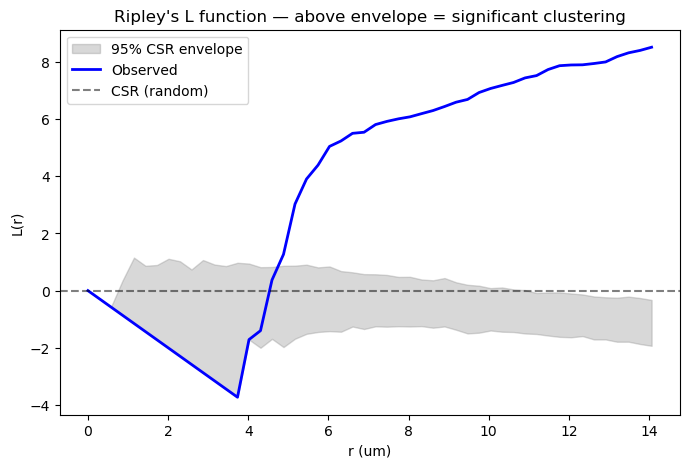

In [16]:
# Ripley's K / L function: spatial clustering at different scales
ripley = sat.computeRipleysK(cell_metrics, px_size=px_size, volume_shape=masks.shape)

r = ripley['r']
plt.figure(figsize=(8, 5))
plt.fill_between(r, ripley['L_envelope_lo'], ripley['L_envelope_hi'],
                 alpha=0.3, color='gray', label='95% CSR envelope')
plt.plot(r, ripley['L_observed'], 'b-', linewidth=2, label='Observed')
plt.axhline(0, color='k', linestyle='--', alpha=0.5, label='CSR (random)')
plt.xlabel('r (um)')
plt.ylabel('L(r)')
plt.title("Ripley's L function — above envelope = significant clustering")
plt.legend()
plt.show()

In [30]:
# Generate metric-painted volumes for visualization in napari/ImageJ
import os

output_dir = os.path.dirname(file_path)

for metric in ['cluster_size', 'shared_boundary_ratio', 'vasa_neighbors', 'clustering_coeff']:
    painted = sat.paintLabelsByMetric(masks, cell_metrics, metric)
    out_path = os.path.join(output_dir, f'{metric}_map.tif')
    tifffile.imwrite(out_path, painted)
    print(f'Saved {out_path}')

Saved Z:\Mikala\connectivity\09092025\cluster_size_map.tif
Saved Z:\Mikala\connectivity\09092025\shared_boundary_ratio_map.tif
Saved Z:\Mikala\connectivity\09092025\vasa_neighbors_map.tif
Saved Z:\Mikala\connectivity\09092025\clustering_coeff_map.tif
